In [87]:
import pandas as pd

import pandas as pd

file_path = r"c:\Users\boban\OneDrive\Desktop\BCI\MOGFormer\data\raw\data_methylation_hm27_hm450_merged.txt"


# Read only the selected columns and the first 10 rows
meth_df = pd.read_csv(file_path, sep="\t", dtype=str)



In [88]:
# -------------------------------------------------------------------------
# Interpretation 1: Unique raw strings as they appear in the column
# -------------------------------------------------------------------------
raw_unique_descriptions = meth_df["DESCRIPTION"].dropna().unique()
print(f"Number of unique raw values: {len(raw_unique_descriptions)}")
print("Raw unique values preview:")
print(raw_unique_descriptions[:20])  # Show first 20 as preview
print("-" * 50)

# -------------------------------------------------------------------------
# Interpretation 2: All unique individual regions (splitting by semicolon ';')
# -------------------------------------------------------------------------
all_individual_regions = set()

for desc in meth_df["DESCRIPTION"].dropna():
    # Split by semicolon and strip any leading/trailing spaces
    for region in str(desc).split(";"):
        all_individual_regions.add(region.strip())

unique_regions = sorted(list(all_individual_regions))
print(f"Number of unique individual regions: {len(unique_regions)}")
print("Unique individual regions:")
print(unique_regions)


Number of unique raw values: 56
Raw unique values preview:
['1stExon' "5'UTR" "Body;5'UTR" 'TSS1500' 'TSS200' 'Body;TSS1500'
 'Body;TSS200' 'Body' 'TSS1500;1stExon' "1stExon;5'UTR" "TSS1500;5'UTR"
 "Body;TSS1500;5'UTR" "1stExon;TSS200;5'UTR" "TSS1500;5'UTR;1stExon"
 'Body;1stExon' "Body;1stExon;5'UTR" 'TSS1500;TSS200' "TSS200;5'UTR"
 '1stExon;TSS200' "TSS1500;1stExon;5'UTR"]
--------------------------------------------------
Number of unique individual regions: 6
Unique individual regions:
['1stExon', "3'UTR", "5'UTR", 'Body', 'TSS1500', 'TSS200']


In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
 
PROMOTER = {"TSS200", "TSS1500", "5'UTR", "1stExon"}
ANN_COLS_DEFAULT = ["ENTITY_STABLE_ID", "NAME", "DESCRIPTION", "TRANSCRIPT_ID"]
 
 
# ----------------------------------------------------------------------
# Step 0: split annotation from patient (value) columns
# ----------------------------------------------------------------------
def split_annotation_and_values(df, ann_cols=ANN_COLS_DEFAULT, id_col="ENTITY_STABLE_ID"):
    """Return (ann, beta). beta is probes x patients, indexed by probe id."""
    ann_cols = [c for c in ann_cols if c in df.columns]
    value_cols = [c for c in df.columns if c not in ann_cols]
    ann = df[ann_cols].copy()
    beta = df.set_index(id_col)[value_cols].apply(pd.to_numeric, errors="coerce")
    return ann, beta
 
 
# ----------------------------------------------------------------------
# Steps 1-2: probe -> (gene, region), keep promoter-proximal only
# ----------------------------------------------------------------------
def probe_to_gene_region(ann, id_col="ENTITY_STABLE_ID"):
    """Explode NAME/DESCRIPTION into (probe, gene, region); keep promoter rows only.
 
    NAME and DESCRIPTION are aligned by gene. When DESCRIPTION collapses to a
    single region but NAME lists several genes, broadcast the region.
    """
    rows = []
    for pid, name, desc in ann[[id_col, "NAME", "DESCRIPTION"]].itertuples(index=False):
        if pd.isna(name) or pd.isna(desc):
            continue
        genes = str(name).split(";")
        regs = str(desc).split(";")
        if len(regs) == 1 and len(genes) > 1:        # shared-region broadcast
            regs = regs * len(genes)
        if len(genes) != len(regs):                  # rare ambiguous case -> skip
            continue
        for g, r in zip(genes, regs):
            r = r.strip()
            if r in PROMOTER:
                rows.append((pid, g.strip(), r))
    pgr = pd.DataFrame(rows, columns=["probe", "gene", "region"])
    return pgr.drop_duplicates(["probe", "gene"])
 
 
# ----------------------------------------------------------------------
# Aggregation: per gene, per patient, over promoter probes
# ----------------------------------------------------------------------
def aggregate_gene(beta, pgr, how="mean"):
    """Return genes x patients matrix aggregated by `how` ('mean' or 'median')."""
    long = pgr.merge(beta, left_on="probe", right_index=True, how="inner")
    grp = long.groupby("gene")[beta.columns]
    out = grp.mean() if how == "mean" else grp.median()
    return out
 
 
def to_mvalue(gene_beta, eps=1e-3):
    """Convert gene-level beta (in [0,1]) to M-values, clipping to avoid +/- inf."""
    b = gene_beta.clip(eps, 1 - eps)
    return np.log2(b / (1 - b))
 
 
# ----------------------------------------------------------------------
# Diagnostic 1: mean vs median comparison
# ----------------------------------------------------------------------
def plot_mean_vs_median(gene_mean, gene_median, sample_n=200_000, seed=0):
    a = gene_mean.values.ravel()
    m = gene_median.values.ravel()
    mask = np.isfinite(a) & np.isfinite(m)
    a, m = a[mask], m[mask]
    if a.size > sample_n:
        idx = np.random.RandomState(seed).choice(a.size, sample_n, replace=False)
        a, m = a[idx], m[idx]
    diff = a - m
 
    fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))
    hb = ax[0].hexbin(m, a, gridsize=60, bins="log", cmap="viridis")
    ax[0].plot([0, 1], [0, 1], "r--", lw=1)
    ax[0].set(xlabel="median beta", ylabel="mean beta", title="mean vs median (gene x patient)")
    fig.colorbar(hb, ax=ax[0], label="log10(count)")
 
    avg = (a + m) / 2
    ax[1].hexbin(avg, diff, gridsize=60, bins="log", cmap="magma")
    ax[1].axhline(0, color="r", ls="--", lw=1)
    ax[1].set(xlabel="(mean + median)/2", ylabel="mean - median",
              title="Bland-Altman (skew map)")
 
    ax[2].hist(diff, bins=120, color="steelblue")
    ax[2].axvline(0, color="r", ls="--", lw=1)
    ax[2].set(xlabel="mean - median", ylabel="count",
              title=f"diff: median={np.median(diff):.4f}, "
                    f"%(>0)={100*(diff>0).mean():.1f}")
    plt.tight_layout()
    plt.show()
    print(f"[mean-median] points={a.size:,}  mean(diff)={diff.mean():.4f}  "
          f"frac(mean>median)={(diff>0).mean():.3f}")
 
 
# ----------------------------------------------------------------------
# PCA helper (samples = patients)
# ----------------------------------------------------------------------
def run_pca(mat, n_components=10, min_finite_frac=0.8):
    """mat: genes x patients. Drops sparse genes, mean-imputes, standardizes, PCA."""
    finite_frac = mat.notna().mean(axis=1)
    mat = mat.loc[finite_frac >= min_finite_frac]
    X = mat.T.values.astype(float)                     # patients x genes
    col_mean = np.nanmean(X, axis=0)
    nan_idx = np.where(np.isnan(X))
    X[nan_idx] = np.take(col_mean, nan_idx[1])
    Xs = StandardScaler().fit_transform(X)
    pca = PCA(n_components=min(n_components, Xs.shape[1], Xs.shape[0])).fit(Xs)
    return pca.transform(Xs), pca, mat.columns
 
 
def plot_pca_pair(gene_mean, gene_median):
    fig, ax = plt.subplots(2, 2, figsize=(12, 9))
    for j, (mat, name) in enumerate([(gene_mean, "mean"), (gene_median, "median")]):
        coords, pca, _ = run_pca(mat)
        ax[0, j].scatter(coords[:, 0], coords[:, 1], s=8, alpha=0.5)
        ax[0, j].set(xlabel="PC1", ylabel="PC2", title=f"PCA of {name} (patients)")
        ev = pca.explained_variance_ratio_
        ax[1, j].bar(range(1, len(ev) + 1), ev, color="slategray")
        ax[1, j].set(xlabel="PC", ylabel="explained var ratio",
                     title=f"scree ({name}); PC1={ev[0]:.2%}")
    plt.tight_layout()
    plt.show()
 
 
# ----------------------------------------------------------------------
# Diagnostic 3: beta -> M-value distribution shift + PCA on M
# ----------------------------------------------------------------------
def plot_mvalue_shift(gene_beta, gene_m, name="mean"):
    b = gene_beta.values.ravel()
    mm = gene_m.values.ravel()
    b, mm = b[np.isfinite(b)], mm[np.isfinite(mm)]
 
    fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))
    ax[0].hist(b, bins=120, color="darkorange")
    ax[0].set(xlabel="beta", ylabel="count", title=f"{name} beta (bounded [0,1])")
    ax[1].hist(mm, bins=120, color="teal")
    ax[1].set(xlabel="M-value", ylabel="count", title=f"{name} M = log2(b/(1-b))")
 
    coords, pca, _ = run_pca(gene_m)
    ev = pca.explained_variance_ratio_
    sc = ax[2].scatter(coords[:, 0], coords[:, 1], s=8, alpha=0.5, c=coords[:, 0],
                       cmap="coolwarm")
    ax[2].set(xlabel="PC1", ylabel="PC2", title=f"PCA of M ({name}); PC1={ev[0]:.2%}")
    plt.tight_layout()
    plt.show()
 
 
# ----------------------------------------------------------------------
# Orchestration
# ----------------------------------------------------------------------
def run_all(meth_df, ann_cols=ANN_COLS_DEFAULT, mvalue_on="mean"):
    """End-to-end: returns dict with gene_mean, gene_median, gene_m matrices."""
    ann, beta = split_annotation_and_values(meth_df, ann_cols)
    pgr = probe_to_gene_region(ann)
    print(f"promoter probe-gene pairs: {len(pgr):,} | "
          f"unique genes: {pgr['gene'].nunique():,} | "
          f"unique probes used: {pgr['probe'].nunique():,}")
 
    gene_mean = aggregate_gene(beta, pgr, how="mean")
    gene_median = aggregate_gene(beta, pgr, how="median")
    print(f"gene x patient matrix: {gene_mean.shape}")
 
    plot_mean_vs_median(gene_mean, gene_median)
    plot_pca_pair(gene_mean, gene_median)
 
    src = gene_mean if mvalue_on == "mean" else gene_median
    gene_m = to_mvalue(src)
    plot_mvalue_shift(src, gene_m, name=mvalue_on)
 
    return {"gene_mean": gene_mean, "gene_median": gene_median,
            "gene_m": gene_m, "pgr": pgr}

promoter probe-gene pairs: 15,277 | unique genes: 10,960 | unique probes used: 14,115
gene x patient matrix: (10960, 1066)


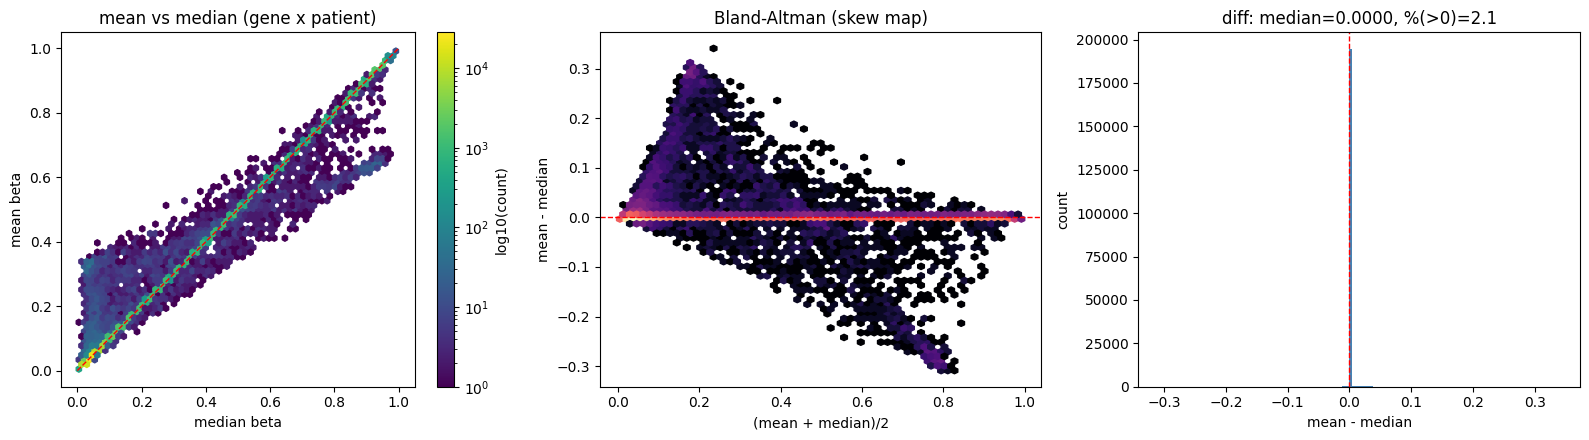

[mean-median] points=200,000  mean(diff)=0.0007  frac(mean>median)=0.021


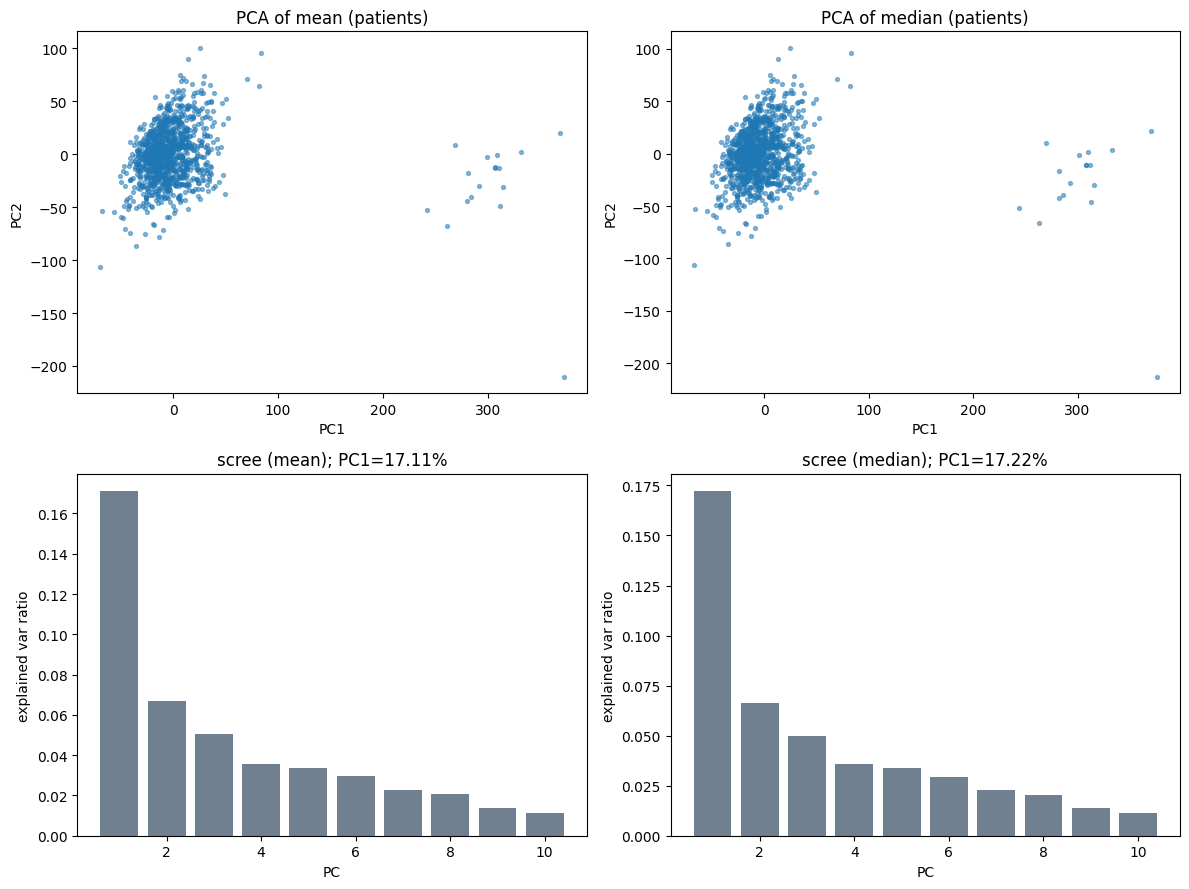

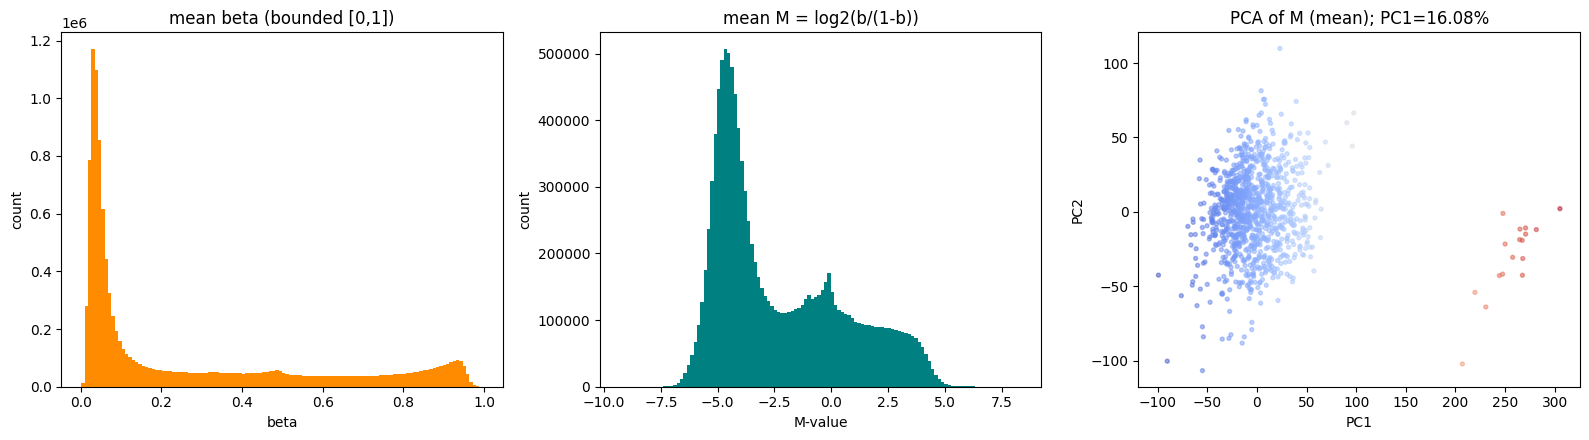

In [67]:
out = run_all(meth_df, mvalue_on="mean")

In [72]:
out.keys()


dict_keys(['gene_mean', 'gene_median', 'gene_m', 'pgr'])

In [76]:
df_meth_M = out["gene_m"]
df_meth_mean = out["gene_mean"]


In [82]:
df_meth_M.columns = [col[:12] if col.startswith("TCGA") else col for col in df_meth_M.columns]
df_meth_mean.columns = [col[:12] if col.startswith("TCGA") else col for col in df_meth_mean.columns]

In [86]:
df_meth_M.to_csv("data/raw/data_methylation_M.csv")
df_meth_mean.to_csv("data/raw/data_methylation_mean.csv")

In [89]:
import pandas as pd

# Paths
meth_file_path = "data/raw/data_cnv.csv"

# 1. Load only the Hugo_Symbol column from the methylation CSV
df_meth = pd.read_csv(meth_file_path, usecols=["Hugo_Symbol"])

# 2. Extract unique, non-null, cleaned gene names from both sources
genes_df = set(df_meth_mean.index.dropna().astype(str).str.strip())
genes_meth = set(df_meth["Hugo_Symbol"].dropna().astype(str).str.strip())

# 3. Calculate intersection and differences
common_genes = genes_df.intersection(genes_meth)
only_in_df = genes_df - genes_meth
only_in_meth = genes_meth - genes_df

# 4. Print results
print(f"Number of genes in df['gene']: {len(genes_df):,}")
print(f"Number of genes in methylation (Hugo_Symbol): {len(genes_meth):,}")
print(f"Number of common genes: {len(common_genes):,}\n")

# Show genes only in df
print(f"Number of genes only in df: {len(only_in_df):,}")
if only_in_df:
    print(f"Genes only in df: {sorted(list(only_in_df))}")
print()

# Show genes only in methylation
print(f"Number of genes only in methylation file: {len(only_in_meth):,}")
if only_in_meth:
    # Shown as a preview since this list can be very long
    preview_limit = 100
    preview_list = sorted(list(only_in_meth))[:preview_limit]
    print(f"Genes only in methylation (first {preview_limit} shown): {preview_list}")


Number of genes in df['gene']: 10,960
Number of genes in methylation (Hugo_Symbol): 25,101
Number of common genes: 10,231

Number of genes only in df: 729
Genes only in df: ['A2BP1', 'ABP1', 'ACCN2', 'ACCN4', 'AGXT2L1', 'AGXT2L2', 'AKD1', 'ANKRD43', 'ANKRD5', 'ANKRD57', 'ANUBL1', 'ARPP-21', 'ASAM', 'ASFMR1', 'ATPBD4', 'B3GNT1', 'BAT2', 'BAT2L2', 'BAT3', 'BAT5', 'BDNFOS', 'BOD1L', 'BPIL1', 'BPIL2', 'BPIL3', 'BRP44L', 'BRUNOL6', 'BTBD12', 'C10orf104', 'C10orf119', 'C10orf125', 'C10orf137', 'C10orf27', 'C10orf4', 'C10orf41', 'C10orf47', 'C10orf57', 'C10orf58', 'C10orf72', 'C10orf81', 'C10orf84', 'C11orf10', 'C11orf2', 'C11orf46', 'C11orf60', 'C11orf61', 'C11orf64', 'C11orf66', 'C11orf67', 'C11orf92', 'C11orf93', 'C12orf11', 'C12orf12', 'C12orf24', 'C12orf26', 'C12orf32', 'C12orf35', 'C12orf44', 'C12orf47', 'C12orf48', 'C12orf62', 'C13orf1', 'C13orf15', 'C13orf16', 'C13orf23', 'C13orf26', 'C13orf27', 'C13orf28', 'C13orf29', 'C13orf30', 'C13orf31', 'C13orf33', 'C13orf34', 'C13orf36', 'C14or

In [98]:

df_meth_M.shape

(10960,)

In [8]:
import pandas as pd



# 1. Load only the Hugo_Symbol column from the methylation CSV
df_cnv = pd.read_csv(r"C:/Users/boban/OneDrive/Desktop/BCI/MOGFormer/data/raw/data_cnv.csv")

df_cnv.shape

(25101, 1030)

In [7]:
# Paths
rna_file_path = "C:/Users/boban/OneDrive/Desktop/BCI/MOGFormer/data/raw/data_rna_seq_v2_rsem.csv"

# 1. Load only the Hugo_Symbol column from the methylation CSV
df_rna = pd.read_csv(rna_file_path)

df_rna.shape

(20511, 1030)

In [35]:
# Paths
meth_file_path = "C:/Users/boban/OneDrive/Desktop/BCI/MOGFormer/data/raw/data_methylation_M.csv"

# 1. Load only the Hugo_Symbol column from the methylation CSV
df_meth = pd.read_csv(meth_file_path)

df_meth.shape

(10960, 1031)

In [39]:
df_meth.head

<bound method NDFrame.head of              Unnamed: 0  TCGA-3C-AAAU  TCGA-3C-AALI  TCGA-3C-AALJ  \
Hugo_Symbol                                                         
A2BP1                 0     -2.265617     -2.807921     -1.705579   
A2M                   1      3.473662      0.149873      3.003656   
A4GALT                2     -0.425956     -0.646037     -1.206922   
AAAS                  3     -3.287589     -4.308780     -3.894291   
AADAC                 4      1.144545      2.492652      2.379515   
...                 ...           ...           ...           ...   
ZWILCH            10955     -4.299610     -4.235354     -4.327251   
ZWINT             10956     -3.870310     -4.136217     -3.852734   
ZYX               10957     -3.194651     -3.143271     -3.607614   
ZZEF1             10958     -3.761295     -3.764403     -3.403521   
ZZZ3              10959     -4.425593     -4.679885     -5.156562   

             TCGA-3C-AALK  TCGA-4H-AAAK  TCGA-5L-AAT0  TCGA-5T-A9QA  \
H

In [20]:
# Find common patient columns (excluding metadata columns like Hugo_Symbol)
common_patients = df_meth.columns.intersection(df_cnv.columns)

# Keep metadata columns + common patient columns
meta_cols = ["Hugo_Symbol"]  # add others if needed, e.g. "Entrez_Gene_Id"
keep_cols = [c for c in meta_cols if c in df_meth.columns] + common_patients.tolist()

df_meth_filtered = df_meth[keep_cols]
print(f"df_meth: {df_meth.shape[1]} cols → {df_meth_filtered.shape[1]} cols ({len(common_patients)} common patients)")


df_meth: 1067 cols → 1031 cols (1030 common patients)


In [45]:
df_meth.columns

Index(['TCGA-3C-AAAU', 'TCGA-3C-AALI', 'TCGA-3C-AALJ', 'TCGA-3C-AALK',
       'TCGA-4H-AAAK', 'TCGA-5L-AAT0', 'TCGA-5T-A9QA', 'TCGA-A1-A0SB',
       'TCGA-A1-A0SD', 'TCGA-A1-A0SE',
       ...
       'TCGA-S3-AA17', 'TCGA-UL-AAZ6', 'TCGA-UU-A93S', 'TCGA-V7-A7HQ',
       'TCGA-W8-A86G', 'TCGA-WT-AB41', 'TCGA-WT-AB44', 'TCGA-XX-A899',
       'TCGA-XX-A89A', 'TCGA-Z7-A8R5'],
      dtype='object', length=1029)

In [46]:
df_meth.to_csv("C:/Users/boban/OneDrive/Desktop/BCI/MOGFormer/data/raw/data_methylation_M.csv", index=True)

In [31]:
df_meth.shape

(10960, 1030)

GENE SET OVERLAP ANALYSIS
  Methylation         : 10,960 unique genes
  RNA-seq             : 20,511 unique genes
  CNV                 : 25,101 unique genes
------------------------------------------------------------
  All three (Meth ∩ RNA ∩ CNV)       : 10,188
  Meth ∩ RNA only                    : 593
  Meth ∩ CNV only                    : 43
  RNA ∩ CNV only                     : 8,720
  Methylation only                   : 136
  RNA-seq only                       : 1,010
  CNV only                           : 6,150


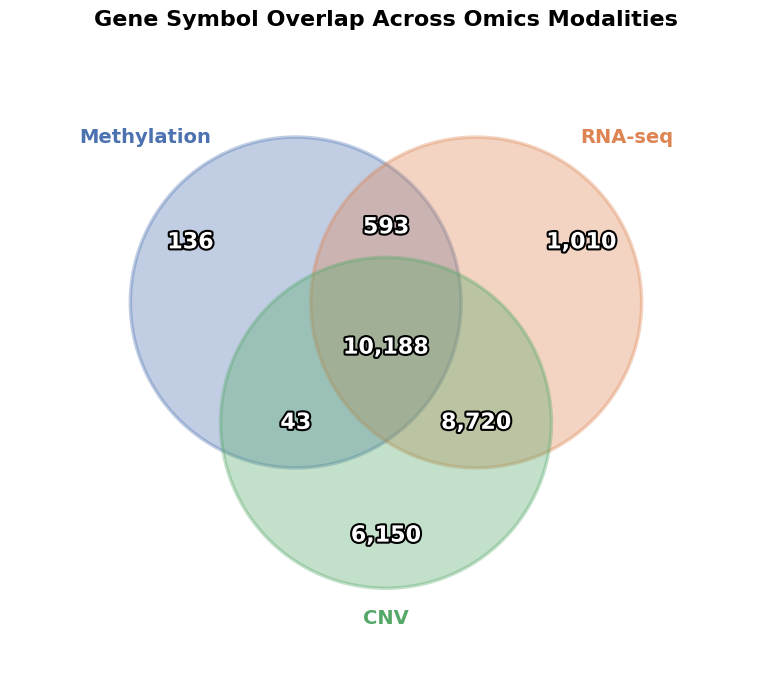

C:\Users\boban\AppData\Local\Temp\ipykernel_21956\3831355771.py:205: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


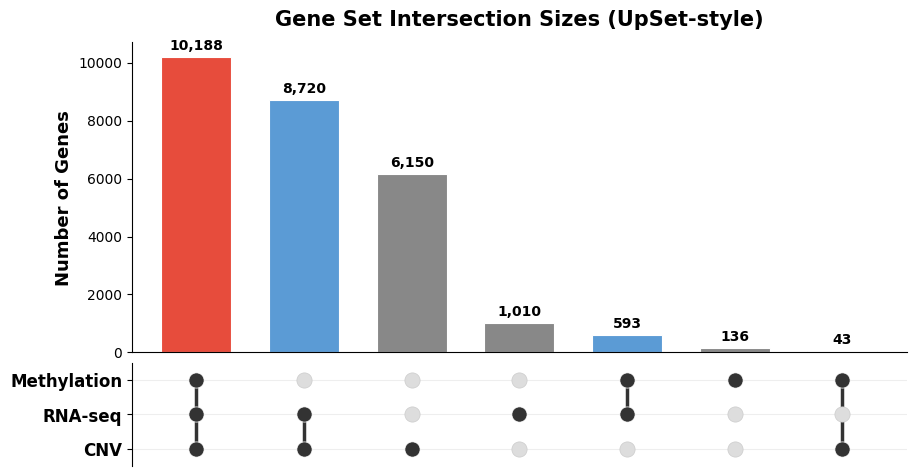



                      Region  Count                                                                                   Genes (first 10)
All three (Meth ∩ RNA ∩ CNV)  10188                              A2M, A4GALT, AAAS, AADAC, AADAT, AAK1, AAMP, AARS, AASDH, AASDHPPT...
              RNA ∩ CNV only   8720                     A1BG, A1CF, A2M-AS1, A2ML1, A4GNT, AACS, AADACL2, AADACL3, AADACL4, AADACP1...
                    CNV only   6150                   A1BG-AS1, A2MP1, A3GALT2, AA06, AACSP1, AADACL2-AS1, AAED1, AAMDC, AAR2, AARD...
                RNA-seq only   1010                        A2LD1, AAA1, AACSL, ACCN1, ACCN3, ACCN5, ACTR2P2, ADAM5P, AFARP1, AFG3L1...
             Meth ∩ RNA only    593                     A2BP1, ABP1, ACCN2, ACCN4, AGXT2L1, AGXT2L2, AKD1, ANKRD43, ANKRD5, ANKRD57...
            Methylation only    136 ARPP-21, B3GNT1, BRUNOL6, C10orf104, C11orf60, C14orf133, C16orf10, C16orf65, C16orf67, C7orf20...
             Meth ∩ CNV only     43             C1QTN

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from matplotlib import patheffects
from itertools import combinations

# =====================================================================
# 1. Extract unique gene sets
# =====================================================================
genes_meth = set(df_meth["Hugo_Symbol"].dropna().astype(str).str.strip().unique())
genes_rna  = set(df_rna["Hugo_Symbol"].dropna().astype(str).str.strip().unique())
genes_cnv  = set(df_cnv["Hugo_Symbol"].dropna().astype(str).str.strip().unique())

sets = {"Methylation": genes_meth, "RNA-seq": genes_rna, "CNV": genes_cnv}

# =====================================================================
# 2. Compute all 7 regions of the Venn diagram
# =====================================================================
all_three   = genes_meth & genes_rna & genes_cnv
meth_rna    = (genes_meth & genes_rna) - genes_cnv
meth_cnv    = (genes_meth & genes_cnv) - genes_rna
rna_cnv     = (genes_rna  & genes_cnv) - genes_meth
only_meth   = genes_meth - genes_rna - genes_cnv
only_rna    = genes_rna  - genes_meth - genes_cnv
only_cnv    = genes_cnv  - genes_meth - genes_rna

regions = {
    "All three (Meth ∩ RNA ∩ CNV)":      all_three,
    "Meth ∩ RNA only":                    meth_rna,
    "Meth ∩ CNV only":                    meth_cnv,
    "RNA ∩ CNV only":                     rna_cnv,
    "Methylation only":                   only_meth,
    "RNA-seq only":                       only_rna,
    "CNV only":                           only_cnv,
}

# Print summary
print("=" * 60)
print("GENE SET OVERLAP ANALYSIS")
print("=" * 60)
for name, s in sets.items():
    print(f"  {name:20s}: {len(s):,} unique genes")
print("-" * 60)
for region, genes in regions.items():
    print(f"  {region:35s}: {len(genes):,}")
print("=" * 60)

# =====================================================================
# 3. Publication-grade Venn diagram (no external dependency)
# =====================================================================
def venn3_custom(sets_dict, ax=None, alpha=0.35):
    """Draw a 3-set Venn diagram using pure matplotlib."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 7))

    names = list(sets_dict.keys())
    A, B, C = [sets_dict[n] for n in names]

    # Circle positions and radius
    r = 2.2
    centers = [(-1.2, 0.6), (1.2, 0.6), (0, -1.0)]
    colors  = ["#4C72B0", "#DD8452", "#55A868"]   # seaborn-inspired

    for center, color, name in zip(centers, colors, names):
        circle = Circle(center, r, alpha=alpha, fc=color, ec=color, lw=2.5)
        ax.add_patch(circle)

    # Region counts and positions (tuned for visual clarity)
    label_data = [
        (len(A - B - C),         (-2.6,  1.4)),    # only A
        (len(B - A - C),         ( 2.6,  1.4)),    # only B
        (len(C - A - B),         ( 0.0, -2.5)),    # only C
        (len(A & B - C),         ( 0.0,  1.6)),    # A∩B only
        (len(A & C - B),         (-1.2, -1.0)),    # A∩C only
        (len(B & C - A),         ( 1.2, -1.0)),    # B∩C only
        (len(A & B & C),         ( 0.0,  0.0)),    # all three
    ]

    for count, (x, y) in label_data:
        txt = ax.text(x, y, f"{count:,}", ha="center", va="center",
                      fontsize=16, fontweight="bold", color="white")
        txt.set_path_effects([
            patheffects.Stroke(linewidth=3, foreground="black"),
            patheffects.Normal()
        ])

    # Set labels
    label_positions = [(-3.2, 2.8), (3.2, 2.8), (0.0, -3.6)]
    for (x, y), name, color in zip(label_positions, names, colors):
        ax.text(x, y, name, ha="center", va="center",
                fontsize=14, fontweight="bold", color=color)

    ax.set_xlim(-5, 5)
    ax.set_ylim(-4.5, 4)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title("Gene Symbol Overlap Across Omics Modalities",
                 fontsize=16, fontweight="bold", pad=15)
    return ax


fig, ax = plt.subplots(figsize=(8, 7), facecolor="white")
venn3_custom(sets, ax=ax)
plt.tight_layout()
plt.savefig("venn_gene_overlap.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

# =====================================================================
# 4. UpSet-style horizontal bar chart (publication standard)
# =====================================================================
def plot_upset(regions, sets_dict, figsize=(10, 5.5)):
    """UpSet-inspired visualization: bar chart + dot matrix."""

    # Sort regions by size (descending)
    sorted_regions = sorted(regions.items(), key=lambda x: len(x[1]), reverse=True)
    labels = [k for k, v in sorted_regions]
    counts = [len(v) for k, v in sorted_regions]
    n = len(labels)
    modalities = list(sets_dict.keys())

    # Determine which modalities are involved in each region
    membership = []
    for label, _ in sorted_regions:
        row = []
        for mod in modalities:
            # Check if the modality name appears in the region label
            mod_lower = mod.lower()
            label_lower = label.lower()
            if mod_lower.startswith("methyl"):
                present = "meth" in label_lower or "all" in label_lower
            elif mod_lower.startswith("rna"):
                present = "rna" in label_lower or "all" in label_lower
            elif mod_lower.startswith("cnv"):
                present = "cnv" in label_lower or "all" in label_lower
            else:
                present = mod_lower in label_lower or "all" in label_lower
            row.append(present)
        membership.append(row)

    # Colors
    bar_colors = []
    palette = {
        1: "#888888",       # single modality (grey)
        2: "#5B9BD5",       # two modalities (blue)
        3: "#E74C3C",       # all three (red)
    }
    for row in membership:
        bar_colors.append(palette[sum(row)])

    # Create figure with two subplots (bar + dot matrix)
    fig, (ax_bar, ax_dot) = plt.subplots(
        2, 1, figsize=figsize, sharex=True,
        gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05}
    )

    x = np.arange(n)

    # --- Bar chart ---
    bars = ax_bar.bar(x, counts, color=bar_colors, edgecolor="white", linewidth=0.8, width=0.65)
    for bar, count in zip(bars, counts):
        ax_bar.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max(counts) * 0.015,
                    f"{count:,}", ha="center", va="bottom", fontsize=10, fontweight="bold")

    ax_bar.set_ylabel("Number of Genes", fontsize=13, fontweight="bold")
    ax_bar.set_title("Gene Set Intersection Sizes (UpSet-style)",
                     fontsize=15, fontweight="bold", pad=12)
    ax_bar.spines["top"].set_visible(False)
    ax_bar.spines["right"].set_visible(False)
    ax_bar.set_xlim(-0.6, n - 0.4)

    # --- Dot matrix ---
    for i, row in enumerate(membership):
        active_indices = [j for j, val in enumerate(row) if val]
        inactive_indices = [j for j, val in enumerate(row) if not val]

        # Draw connecting line between active dots
        if len(active_indices) > 1:
            ax_dot.plot([i, i],
                        [min(active_indices), max(active_indices)],
                        color="#333333", lw=2.5, zorder=1)

        # Active dots (filled)
        for j in active_indices:
            ax_dot.scatter(i, j, s=120, color="#333333", zorder=2,
                           edgecolor="white", linewidth=0.5)
        # Inactive dots (empty)
        for j in inactive_indices:
            ax_dot.scatter(i, j, s=120, color="#DDDDDD", zorder=2,
                           edgecolor="#CCCCCC", linewidth=0.5)

    ax_dot.set_yticks(range(len(modalities)))
    ax_dot.set_yticklabels(modalities, fontsize=12, fontweight="bold")
    ax_dot.set_xticks([])
    ax_dot.set_ylim(-0.5, len(modalities) - 0.5)
    ax_dot.invert_yaxis()
    ax_dot.spines["top"].set_visible(False)
    ax_dot.spines["right"].set_visible(False)
    ax_dot.spines["bottom"].set_visible(False)

    # Add light horizontal gridlines
    for j in range(len(modalities)):
        ax_dot.axhline(j, color="#EEEEEE", lw=0.8, zorder=0)

    plt.tight_layout()
    plt.savefig("upset_gene_overlap.png", dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()


plot_upset(regions, sets)

# =====================================================================
# 5. Summary table (for supplementary material)
# =====================================================================
summary_rows = []
for region, genes in regions.items():
    gene_list = sorted(genes)
    summary_rows.append({
        "Region": region,
        "Count": len(genes),
        "Genes (first 10)": ", ".join(gene_list[:10]) + ("..." if len(gene_list) > 10 else "")
    })

df_summary = pd.DataFrame(summary_rows).sort_values("Count", ascending=False).reset_index(drop=True)
print("\n")
print(df_summary.to_string(index=False))


PATIENT ID OVERLAP ANALYSIS
  Methylation         : 1,029 patients
  RNA-seq             : 1,029 patients
  CNV                 : 1,029 patients
------------------------------------------------------------
  All three (Meth ∩ RNA ∩ CNV)       : 1,029
  Meth ∩ RNA only                    : 0
  Meth ∩ CNV only                    : 0
  RNA ∩ CNV only                     : 0
  Methylation only                   : 0
  RNA-seq only                       : 0
  CNV only                           : 0


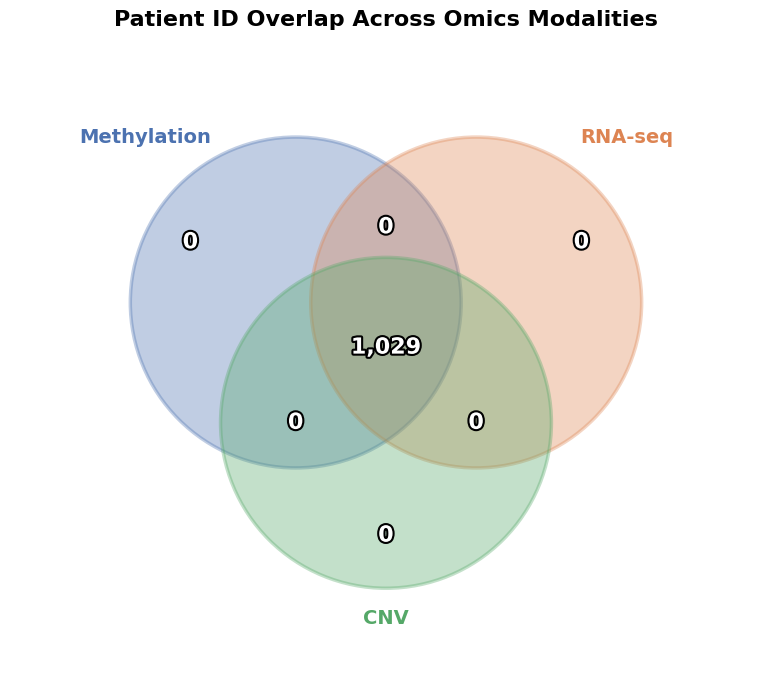

C:\Users\boban\AppData\Local\Temp\ipykernel_21956\3831355771.py:205: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


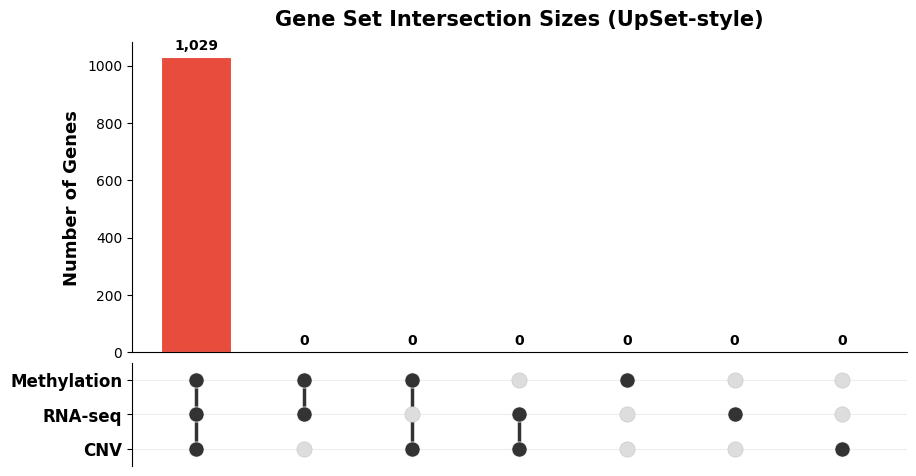



                      Region  Count                                                                                                                           Patients (first 10)
All three (Meth ∩ RNA ∩ CNV)   1029 TCGA-3C-AAAU, TCGA-3C-AALI, TCGA-3C-AALJ, TCGA-3C-AALK, TCGA-4H-AAAK, TCGA-5L-AAT0, TCGA-5T-A9QA, TCGA-A1-A0SB, TCGA-A1-A0SD, TCGA-A1-A0SE...
             Meth ∩ RNA only      0                                                                                                                                              
             Meth ∩ CNV only      0                                                                                                                                              
              RNA ∩ CNV only      0                                                                                                                                              
            Methylation only      0                                                                         

In [32]:
# =====================================================================
# 1. Extract unique patient ID sets from column names
# =====================================================================
# Exclude non-patient columns (metadata/annotation columns)
non_patient_cols = {"Hugo_Symbol", "ENTITY_STABLE_ID", "NAME", "DESCRIPTION", "TRANSCRIPT_ID", 
                    "Entrez_Gene_Id", "gene", "probe", "region"}

patients_meth = set(c for c in df_meth.columns if c not in non_patient_cols)
patients_rna  = set(c for c in df_rna.columns  if c not in non_patient_cols)
patients_cnv  = set(c for c in df_cnv.columns  if c not in non_patient_cols)

sets = {"Methylation": patients_meth, "RNA-seq": patients_rna, "CNV": patients_cnv}

# =====================================================================
# 2. Compute all 7 regions of the Venn diagram
# =====================================================================
all_three   = patients_meth & patients_rna & patients_cnv
meth_rna    = (patients_meth & patients_rna) - patients_cnv
meth_cnv    = (patients_meth & patients_cnv) - patients_rna
rna_cnv     = (patients_rna  & patients_cnv) - patients_meth
only_meth   = patients_meth - patients_rna - patients_cnv
only_rna    = patients_rna  - patients_meth - patients_cnv
only_cnv    = patients_cnv  - patients_meth - patients_rna

regions = {
    "All three (Meth ∩ RNA ∩ CNV)":      all_three,
    "Meth ∩ RNA only":                    meth_rna,
    "Meth ∩ CNV only":                    meth_cnv,
    "RNA ∩ CNV only":                     rna_cnv,
    "Methylation only":                   only_meth,
    "RNA-seq only":                       only_rna,
    "CNV only":                           only_cnv,
}

# Print summary
print("=" * 60)
print("PATIENT ID OVERLAP ANALYSIS")
print("=" * 60)
for name, s in sets.items():
    print(f"  {name:20s}: {len(s):,} patients")
print("-" * 60)
for region, pats in regions.items():
    print(f"  {region:35s}: {len(pats):,}")
print("=" * 60)

# =====================================================================
# 3. Venn diagram
# =====================================================================
fig, ax = plt.subplots(figsize=(8, 7), facecolor="white")
venn3_custom(sets, ax=ax)
ax.set_title("Patient ID Overlap Across Omics Modalities",
             fontsize=16, fontweight="bold", pad=15)
plt.tight_layout()
plt.savefig("venn_patient_overlap.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

# =====================================================================
# 4. UpSet-style bar chart
# =====================================================================
plot_upset(regions, sets)

# =====================================================================
# 5. Summary table
# =====================================================================
summary_rows = []
for region, pats in regions.items():
    pat_list = sorted(pats)
    summary_rows.append({
        "Region": region,
        "Count": len(pats),
        "Patients (first 10)": ", ".join(pat_list[:10]) + ("..." if len(pat_list) > 10 else "")
    })

df_summary = pd.DataFrame(summary_rows).sort_values("Count", ascending=False).reset_index(drop=True)
print("\n")
print(df_summary.to_string(index=False))


In [11]:
# Paths
clin_file_path = "C:/Users/boban/OneDrive/Desktop/BCI/MOGFormer/data/raw/data_clinical.csv"

# 1. Load only the Hugo_Symbol column from the methylation CSV
df_clin = pd.read_csv(clin_file_path)

df_clin.shape

(1021, 35)

In [17]:
df_clin.columns

Index(['patient ', 'clinical__cases.disease_type',
       'clinical__cases.lost_to_followup',
       'clinical__demographic.age_at_index',
       'clinical__demographic.days_to_death',
       'clinical__demographic.ethnicity', 'clinical__demographic.race',
       'clinical__diagnoses.ajcc_pathologic_m',
       'clinical__diagnoses.ajcc_pathologic_n',
       'clinical__diagnoses.ajcc_pathologic_stage',
       'clinical__diagnoses.ajcc_pathologic_t',
       'clinical__diagnoses.ajcc_staging_system_edition',
       'clinical__diagnoses.classification_of_tumor',
       'clinical__diagnoses.days_to_last_follow_up',
       'clinical__diagnoses.metastasis_at_diagnosis',
       'clinical__diagnoses.synchronous_malignancy',
       'clinical__diagnoses.year_of_diagnosis',
       'clinical__treatments.days_to_treatment_end',
       'clinical__treatments.days_to_treatment_start',
       'clinical__treatments.number_of_cycles',
       'clinical__treatments.prescribed_dose',
       'clinical__treatm

PATIENT OVERLAP ANALYSIS (4 MODALITIES — with subtyped clinical)
  Methylation         : 1,029 patients
  RNA-seq             : 1,029 patients
  CNV                 : 1,029 patients
  Clinical            : 949 patients
----------------------------------------------------------------------
  Methylation ∩ RNA-seq ∩ CNV ∩ Clinical                 : 949
  Methylation ∩ RNA-seq ∩ CNV only                       : 80


C:\Users\boban\AppData\Local\Temp\ipykernel_21956\3683921213.py:143: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


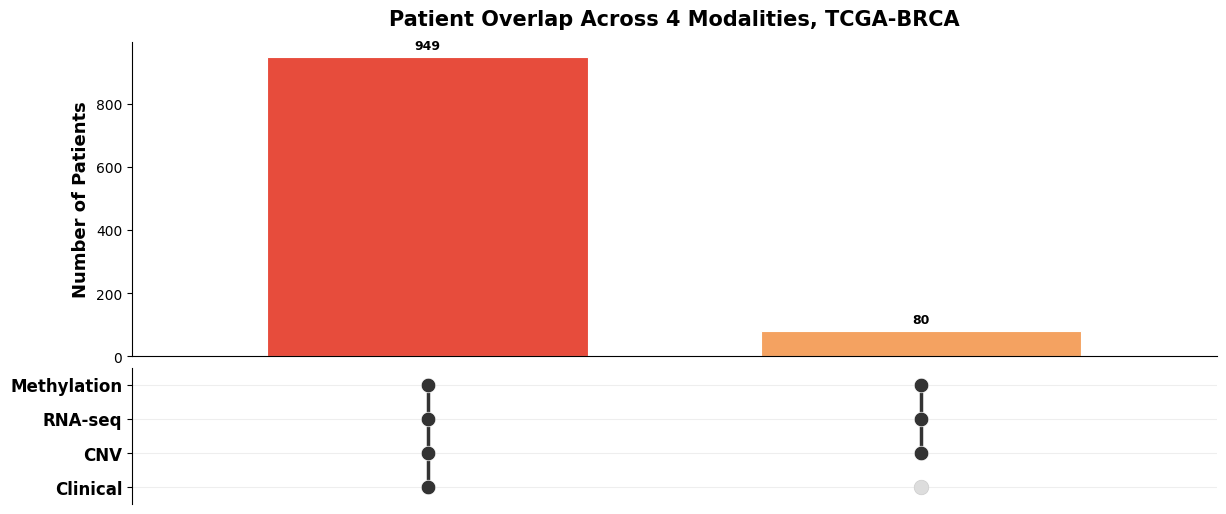



                                Region  Count                                                                                                                           Patients (first 10)
Methylation ∩ RNA-seq ∩ CNV ∩ Clinical    949 TCGA-3C-AAAU, TCGA-3C-AALI, TCGA-3C-AALJ, TCGA-3C-AALK, TCGA-4H-AAAK, TCGA-5L-AAT0, TCGA-5T-A9QA, TCGA-A1-A0SB, TCGA-A1-A0SD, TCGA-A1-A0SE...
      Methylation ∩ RNA-seq ∩ CNV only     80 TCGA-A2-A0CO, TCGA-A2-A3KC, TCGA-A2-A3XS, TCGA-A2-A3XY, TCGA-A2-A4RW, TCGA-A2-A4RX, TCGA-A2-A4RY, TCGA-A2-A4S0, TCGA-A7-A0DC, TCGA-A7-A13H...


In [33]:
# =====================================================================
# 1. Extract patient sets (reuse the 3 omics sets from before)
# =====================================================================
# Clinical patients that have a non-null, non-empty SUBTYPE
patients_clin = set(
    df_clin.loc[df_clin["SUBTYPE"].notna() & (df_clin["SUBTYPE"].str.strip() != ""),
                "patient "]
    .astype(str).str.strip().unique()
)

sets4 = {
    "Methylation": patients_meth,
    "RNA-seq":     patients_rna,
    "CNV":         patients_cnv,
    "Clinical":    patients_clin,
}

# =====================================================================
# 2. Compute all 15 regions of a 4-set overlap
# =====================================================================
from itertools import combinations

modalities = list(sets4.keys())
all_patients = set().union(*sets4.values())

def get_region(combo, all_keys, sets_dict):
    """Patients in ALL of `combo` but NONE of the others."""
    included = set.intersection(*(sets_dict[k] for k in combo))
    excluded_keys = [k for k in all_keys if k not in combo]
    for k in excluded_keys:
        included = included - sets_dict[k]
    return included

regions4 = {}
# From 4-way down to 1-way intersections
for size in range(len(modalities), 0, -1):
    for combo in combinations(modalities, size):
        label = " ∩ ".join(combo)
        if size < len(modalities):
            label += " only"
        region = get_region(combo, modalities, sets4)
        regions4[label] = region

# Remove empty regions for cleaner display
regions4 = {k: v for k, v in regions4.items() if len(v) > 0}

# Print summary
print("=" * 70)
print("PATIENT OVERLAP ANALYSIS (4 MODALITIES — with subtyped clinical)")
print("=" * 70)
for name, s in sets4.items():
    print(f"  {name:20s}: {len(s):,} patients")
print("-" * 70)
for region, pats in sorted(regions4.items(), key=lambda x: -len(x[1])):
    print(f"  {region:55s}: {len(pats):,}")
print("=" * 70)

# =====================================================================
# 3. 4-set UpSet plot
# =====================================================================
def plot_upset_4(regions, sets_dict, figsize=(14, 6)):
    """UpSet plot generalized for any number of sets."""
    mod_names = list(sets_dict.keys())

    # Sort regions by size (descending)
    sorted_regions = sorted(regions.items(), key=lambda x: len(x[1]), reverse=True)
    labels = [k for k, v in sorted_regions]
    counts = [len(v) for k, v in sorted_regions]
    n = len(labels)

    # Determine membership for each region
    membership = []
    for label, _ in sorted_regions:
        row = []
        for mod in mod_names:
            # A modality is "active" if its name (or a recognizable abbreviation) is in the label
            mod_check = mod.lower()
            label_lower = label.lower()
            if mod_check.startswith("methyl"):
                present = "methyl" in label_lower
            elif mod_check.startswith("rna"):
                present = "rna" in label_lower
            elif mod_check.startswith("cnv"):
                present = "cnv" in label_lower
            elif mod_check.startswith("clin"):
                present = "clin" in label_lower
            else:
                present = mod_check in label_lower
            row.append(present)
        membership.append(row)

    # Colors by number of active sets
    palette = {1: "#AAAAAA", 2: "#5B9BD5", 3: "#F4A261", 4: "#E74C3C"}

    fig, (ax_bar, ax_dot) = plt.subplots(
        2, 1, figsize=figsize, sharex=True,
        gridspec_kw={"height_ratios": [3, 1.3], "hspace": 0.05}
    )

    x = np.arange(n)

    # --- Bar chart ---
    bar_colors = [palette.get(sum(row), "#888888") for row in membership]
    bars = ax_bar.bar(x, counts, color=bar_colors, edgecolor="white", linewidth=0.8, width=0.65)
    for bar, count in zip(bars, counts):
        ax_bar.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + max(counts) * 0.015,
                    f"{count:,}", ha="center", va="bottom", fontsize=9, fontweight="bold")

    ax_bar.set_ylabel("Number of Patients", fontsize=13, fontweight="bold")
    ax_bar.set_title("Patient Overlap Across 4 Modalities, TCGA-BRCA",
                     fontsize=15, fontweight="bold", pad=12)
    ax_bar.spines["top"].set_visible(False)
    ax_bar.spines["right"].set_visible(False)
    ax_bar.set_xlim(-0.6, n - 0.4)

    # --- Dot matrix ---
    for i, row in enumerate(membership):
        active_idx   = [j for j, val in enumerate(row) if val]
        inactive_idx = [j for j, val in enumerate(row) if not val]

        if len(active_idx) > 1:
            ax_dot.plot([i, i], [min(active_idx), max(active_idx)],
                        color="#333333", lw=2.5, zorder=1)
        for j in active_idx:
            ax_dot.scatter(i, j, s=110, color="#333333", zorder=2,
                           edgecolor="white", linewidth=0.5)
        for j in inactive_idx:
            ax_dot.scatter(i, j, s=110, color="#DDDDDD", zorder=2,
                           edgecolor="#CCCCCC", linewidth=0.5)

    ax_dot.set_yticks(range(len(mod_names)))
    ax_dot.set_yticklabels(mod_names, fontsize=12, fontweight="bold")
    ax_dot.set_xticks([])
    ax_dot.set_ylim(-0.5, len(mod_names) - 0.5)
    ax_dot.invert_yaxis()
    ax_dot.spines["top"].set_visible(False)
    ax_dot.spines["right"].set_visible(False)
    ax_dot.spines["bottom"].set_visible(False)
    for j in range(len(mod_names)):
        ax_dot.axhline(j, color="#EEEEEE", lw=0.8, zorder=0)

    plt.tight_layout()
    plt.savefig("upset_patient_overlap_4sets.png", dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()


plot_upset_4(regions4, sets4)

# =====================================================================
# 4. Summary table
# =====================================================================
summary_rows = []
for region, pats in sorted(regions4.items(), key=lambda x: -len(x[1])):
    pat_list = sorted(pats)
    summary_rows.append({
        "Region": region,
        "Count": len(pats),
        "Patients (first 10)": ", ".join(pat_list[:10]) + ("..." if len(pat_list) > 10 else "")
    })

df_summary = pd.DataFrame(summary_rows).reset_index(drop=True)
print("\n")
print(df_summary.to_string(index=False))

